# Notebook 07: Dataset Creation

## Objective

This notebook generates the processed dataset that will be used for all
subsequent deep learning experiments.

The pipeline consists of:

Raw CT (.nii.gz)
        +
Segmentation Mask (.nii.gz)
        +
Clinical Metadata (.xlsx)

        ↓

Preprocessing
    • Resampling
    • HU Clipping
    • Min-Max Normalization
    • Fixed ROI Cropping

        ↓

Processed Dataset (.npy)

        ↓

metadata.csv

The preprocessing logic is implemented in `src/preprocessing.py`.
This notebook only demonstrates its usage.

In [2]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\Pancreatic_Cancer_Thesis


In [3]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import src.preprocessing as prep
from src.io import (
    load_metadata,
    list_ct_cases,
)

In [4]:
BATCH_NAME = "batch_1"

OVERWRITE = False

VERIFY_AFTER_PROCESSING = True

In [5]:
metadata = load_metadata()

print(metadata.head())

print()

print(f"Total studies : {len(metadata)}")

print(metadata["label"].value_counts())

   PANORAMA_patient_id PANORAMA_study_id anonymized_study_date patient_age  \
0               100000      100000_00001            2018-10-04        042Y   
1               100001      100001_00001            2014-04-24        068Y   
2               100002      100002_00001            2021-03-02        077Y   
3               100003      100003_00001            2016-12-28        057Y   
4               100004      100004_00001            2018-02-09        068Y   

  patient_sex  scanner     label      level  
0           F  TOSHIBA  non-PDAC  radiology  
1           M  SIEMENS  non-PDAC  radiology  
2           F  TOSHIBA      PDAC  pathology  
3           M  TOSHIBA      PDAC   cytology  
4           M  SIEMENS  non-PDAC  radiology  

Total studies : 2238
label
non-PDAC    1562
PDAC         676
Name: count, dtype: int64


In [5]:
study_ids = sorted(list_ct_cases())

len(study_ids)

557

In [12]:
processed_metadata = prep.process_dataset(
    study_ids=study_ids,
    overwrite=OVERWRITE,
)

Processing dataset:   0%|          | 0/557 [00:00<?, ?it/s]

Skipping 100000_00001
Skipping 100001_00001
Skipping 100002_00001
Skipping 100003_00001
Skipping 100004_00001
Skipping 100005_00001
Skipping 100006_00001
Skipping 100007_00001
Skipping 100008_00001
Skipping 100009_00001
Skipping 100010_00001
Skipping 100011_00001
Skipping 100012_00001
Skipping 100013_00001
Skipping 100014_00001
Skipping 100015_00001
Skipping 100016_00001
Skipping 100017_00001
Skipping 100018_00001
Skipping 100019_00001
Skipping 100020_00001
Skipping 100021_00001
Skipping 100022_00001
Skipping 100023_00001
Skipping 100024_00001
Skipping 100025_00001
Skipping 100026_00001
Skipping 100027_00001
Skipping 100028_00001
Skipping 100029_00001
Skipping 100030_00001
Skipping 100031_00001
Skipping 100032_00001
Skipping 100033_00001
Skipping 100034_00001
Skipping 100035_00001
Skipping 100036_00001
Skipping 100037_00001
Skipping 100038_00001
Skipping 100039_00001
Skipping 100040_00001
Skipping 100041_00001
Skipping 100042_00001
Skipping 100043_00001
Skipping 100044_00001
Skipping 1

ValueError: No metadata records were provided.

In [7]:
summary, report = prep.verify_dataset()

report

Verifying dataset:   0%|          | 0/556 [00:00<?, ?it/s]

Processed Dataset Verification
num_cases                : 556
missing_images           : 0
missing_masks            : 0
invalid_image_shape      : 0
invalid_mask_shape       : 0
invalid_image_dtype      : 0
invalid_mask_dtype       : 0
invalid_image_range      : 0
invalid_mask_labels      : 0
duplicate_study_ids      : 0

✓ All processed cases passed verification.


,study_id,status,issues,image_min,image_max,mask_labels
0,100000_00001,PASS,,0.0,1.0,"0,2,3,4,6"
1,100001_00001,PASS,,0.0,1.0,"0,2,3,4,5,6"
2,100002_00001,PASS,,0.0,1.0,"0,1,2,3,4,5,6"
3,100003_00001,PASS,,0.0,1.0,"0,1,2,3,4,5,6"
4,100004_00001,PASS,,0.0,1.0,"0,2,3,4,5,6"
...,...,...,...,...,...,...
551,100542_00001,PASS,,0.0,1.0,"0,1,2,3,4,5,6"
552,100543_00001,PASS,,0.0,1.0,"0,2,3,4,5,6"
553,100544_00001,PASS,,0.0,1.0,"0,1,2,3,4,5,6"
554,100545_00001,PASS,,0.0,1.0,"0,1,2,3,4,5,6"


In [13]:
len(load_metadata())

2238

In [14]:
processed = pd.read_csv(prep.PROCESSED_DIR / "metadata.csv")

print(len(processed))

556


In [16]:
raw_ids = set(list_ct_cases())

processed_ids = set(
    pd.read_csv(prep.PROCESSED_DIR / "metadata.csv")["study_id"]
)

missing = sorted(raw_ids - processed_ids)

print("Missing:", len(missing))
missing[:20]

Missing: 1


['100433_00001']

In [18]:
study_id = "100009_00001"

print("Loading:", study_id)

case = prep.load_case(study_id)

print("Loaded successfully")

Loading: 100009_00001
Loaded successfully


In [19]:
case = prep.preprocess_case(case)

print("Preprocessing successful")

After Resample   : -1024.0 1410.1887
After Clip       : -150.0 250.0
After Normalize  : 0.0 1.0
After Crop       : 0.0 1.0
After Pad        : 0.0 1.0
Final            : 0.0 1.0
Preprocessing successful


In [20]:
failed = []

for study_id in missing:

    try:
        case = prep.load_case(study_id)
        case = prep.preprocess_case(case)

    except Exception as e:

        failed.append(
            {
                "study_id": study_id,
                "error": str(e),
            }
        )

import pandas as pd

failed_df = pd.DataFrame(failed)

print(failed_df)

       study_id                                              error
0  100433_00001  Exception thrown in SimpleITK ImageFileReader_...


In [23]:
metadata = pd.read_csv(prep.PROCESSED_DIR / "metadata.csv")

print(metadata["study_id"].eq("100009_00001").any())

True


In [24]:
clinical = load_metadata()

print(
    clinical["patient_age"].isna().sum()
)

274


In [25]:
prep.repair_metadata()

Repairing metadata:   0%|          | 0/556 [00:00<?, ?it/s]

Metadata already complete.


,study_id,label,image_path,mask_path,image_shape,mask_shape,image_dtype,mask_dtype,mask_labels,patient_id,patient_age,patient_sex,scanner,diagnosis,diagnosis_source,roi_size,target_spacing,hu_window
0,100000_00001,NaN,images\100000_00001.npy,masks\100000_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,2,3,4,6",100000,42.0,F,TOSHIBA,non-PDAC,radiology,"128,160,192","1.0,1.0,3.0","-150,250"
1,100001_00001,NaN,images\100001_00001.npy,masks\100001_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,2,3,4,5,6",100001,68.0,M,SIEMENS,non-PDAC,radiology,"128,160,192","1.0,1.0,3.0","-150,250"
2,100002_00001,NaN,images\100002_00001.npy,masks\100002_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,1,2,3,4,5,6",100002,77.0,F,TOSHIBA,PDAC,pathology,"128,160,192","1.0,1.0,3.0","-150,250"
3,100003_00001,NaN,images\100003_00001.npy,masks\100003_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,1,2,3,4,5,6",100003,57.0,M,TOSHIBA,PDAC,cytology,"128,160,192","1.0,1.0,3.0","-150,250"
4,100004_00001,NaN,images\100004_00001.npy,masks\100004_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,2,3,4,5,6",100004,68.0,M,SIEMENS,non-PDAC,radiology,"128,160,192","1.0,1.0,3.0","-150,250"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,100542_00001,NaN,images\100542_00001.npy,masks\100542_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,1,2,3,4,5,6",100542,NaN,NaN,NaN,PDAC,MSD_dataset,"128,160,192","1.0,1.0,3.0","-150,250"
552,100543_00001,NaN,images\100543_00001.npy,masks\100543_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,2,3,4,5,6",100543,NaN,NaN,NaN,non-PDAC,NIH_dataset,"128,160,192","1.0,1.0,3.0","-150,250"
553,100544_00001,NaN,images\100544_00001.npy,masks\100544_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,1,2,3,4,5,6",100544,76.0,F,Philips,PDAC,pathology,"128,160,192","1.0,1.0,3.0","-150,250"
554,100545_00001,NaN,images\100545_00001.npy,masks\100545_00001.npy,"128,160,192","128,160,192",float32,uint8,"0,1,2,3,4,5,6",100545,72.0,F,TOSHIBA,PDAC,pathology,"128,160,192","1.0,1.0,3.0","-150,250"


In [26]:
summary, report = prep.verify_dataset()

Verifying dataset:   0%|          | 0/556 [00:00<?, ?it/s]

Processed Dataset Verification
num_cases                : 556
missing_images           : 0
missing_masks            : 0
invalid_image_shape      : 0
invalid_mask_shape       : 0
invalid_image_dtype      : 0
invalid_mask_dtype       : 0
invalid_image_range      : 0
invalid_mask_labels      : 0
duplicate_study_ids      : 0

✓ All processed cases passed verification.


In [27]:
raw_ids = set(prep.list_ct_cases())

metadata = pd.read_csv(prep.PROCESSED_DIR / "metadata.csv")
metadata_ids = set(metadata["study_id"])

print("Raw CT cases       :", len(raw_ids))
print("Metadata cases     :", len(metadata_ids))
print("Missing in metadata:", len(raw_ids - metadata_ids))
print("Extra in metadata  :", len(metadata_ids - raw_ids))

Raw CT cases       : 557
Metadata cases     : 556
Missing in metadata: 1
Extra in metadata  : 0


In [28]:
print(next(iter(raw_ids - metadata_ids)))

100433_00001


In [5]:
study_id = "100433_00001"

print(
    (prep.PROCESSED_IMAGES_DIR / f"{study_id}.npy").exists()
)

print(
    (prep.PROCESSED_MASKS_DIR / f"{study_id}.npy").exists()
)

False
False


In [30]:
clinical = prep.load_metadata()

clinical = clinical.rename(
    columns={
        "PANORAMA_study_id": "study_id",
    }
)

print(
    clinical["study_id"].eq(study_id).any()
)

True


In [31]:
case = prep.load_case(study_id)

print(case.keys())

RuntimeError: Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(00000213C74F1D60): nifti_image_load failed for file: D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100433_00001.nii.gz

In [32]:
case = prep.preprocess_case(case)

print("Success")

After Resample   : -1024.0 1410.1887
After Clip       : -150.0 250.0
After Normalize  : 0.0 1.0
After Crop       : 0.0 1.0
After Pad        : 0.0 1.0
Final            : 0.0 1.0
Success


In [33]:
from pathlib import Path

path = (
    prep.AUTOMATIC_LABELS_DIR /
    "100433_00001.nii.gz"
)

print(path.exists())
print(path.stat().st_size)

AttributeError: module 'src.preprocessing' has no attribute 'AUTOMATIC_LABELS_DIR'

In [34]:
from src.config import AUTO_LABEL_DIR

path = AUTO_LABEL_DIR / "100433_00001.nii.gz"

print(path)
print(path.exists())
print(path.stat().st_size / 1024 / 1024, "MB")

D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100433_00001.nii.gz
True
7.547481536865234 MB


In [35]:
import SimpleITK as sitk

sitk.ReadImage(str(path))

RuntimeError: Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\bld\ITK\Modules\IO\NIFTI\src\itkNiftiImageIO.cxx:597:
ITK ERROR: NiftiImageIO(00000213CBAAEBC0): nifti_image_load failed for file: D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100433_00001.nii.gz

In [22]:
import nibabel as nib

nib.load(str(path))

In [36]:
import nibabel as nib

img = nib.load(str(path))

print(img)
print(img.header)
print("Shape:", img.shape)
print("Data type:", img.get_data_dtype())


<class 'nibabel.nifti1.Nifti1Image'>
data shape (1024, 1024, 945)
affine:
[[-4.23431009e-01  0.00000000e+00  0.00000000e+00  2.06819534e+02]
 [ 0.00000000e+00 -4.23431009e-01  0.00000000e+00  2.16585159e+02]
 [ 0.00000000e+00  0.00000000e+00  5.00000000e-01  1.03200000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [   3 1024 1024  945    1    1    1    1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [1.       0.423431 0.423431 0.5      0.       0.       0.       0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2


In [37]:
import nibabel as nib

img = nib.load(str(path))

new_path = AUTO_LABEL_DIR / "100433_00001_fixed.nii.gz"

nib.save(img, str(new_path))

print(new_path)

MemoryError: 

In [38]:
summary = prep.verify_dataset()

print("\nDataset production completed.")
print("Successfully processed:", summary["num_cases"])

Verifying dataset:   0%|          | 0/556 [00:00<?, ?it/s]

Processed Dataset Verification
num_cases                : 556
missing_images           : 0
missing_masks            : 0
invalid_image_shape      : 0
invalid_mask_shape       : 0
invalid_image_dtype      : 0
invalid_mask_dtype       : 0
invalid_image_range      : 0
invalid_mask_labels      : 0
duplicate_study_ids      : 0

✓ All processed cases passed verification.

Dataset production completed.


TypeError: tuple indices must be integers or slices, not str

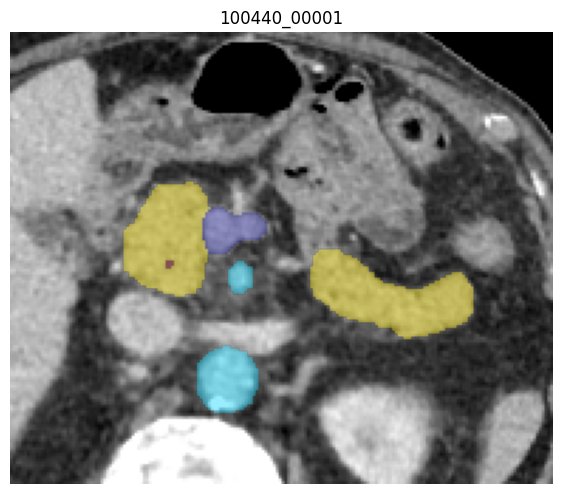

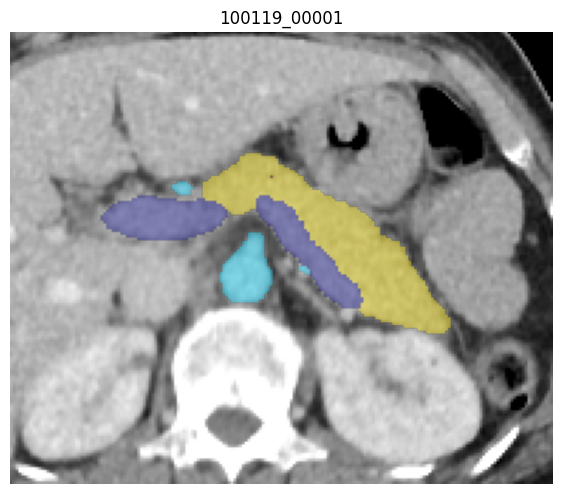

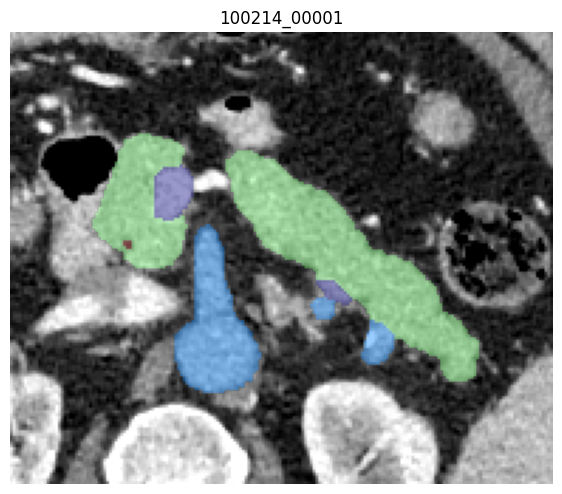

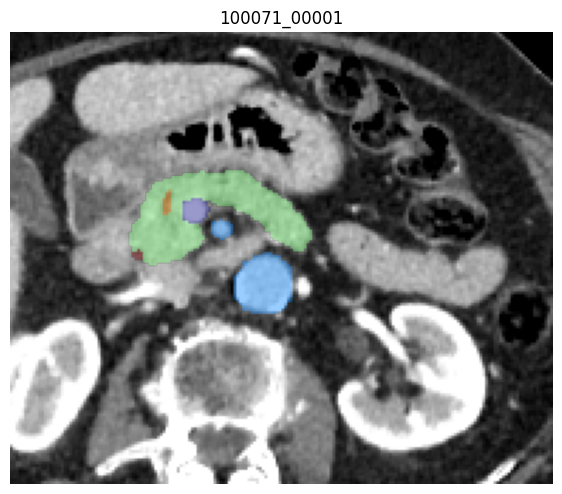

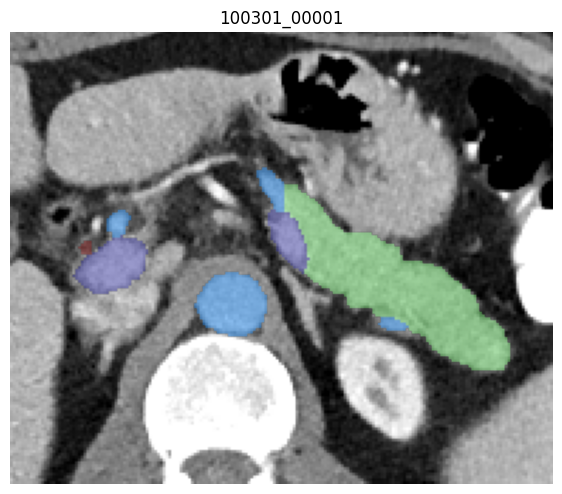

In [40]:
import src.visualization as vis
metadata = pd.read_csv(
    prep.PROCESSED_DIR / "metadata.csv"
)

for study_id in metadata.sample(5)["study_id"]:
    vis.show_processed_case(study_id)

In [11]:
# ============================================================
# PROCESS RECOVERED CASE: 100433_00001
# ============================================================

from pathlib import Path

study_id = "100433_00001"

automatic_labels_dir = Path(
    "D:/Pancreatic_Cancer_Thesis/data/labels/Automatic_Labels"
)

mask_path = automatic_labels_dir / f"{study_id}.nii.gz"
backup_path = automatic_labels_dir / f"{study_id}_original_backup.nii.gz"

print("=" * 60)
print("PROCESSING RECOVERED CASE")
print("=" * 60)

print("Study ID:", study_id)
print()
print("Mask being used:")
print(mask_path)

print("\nOriginal backup:")
print(backup_path)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if not mask_path.exists():
    raise FileNotFoundError(
        f"Repaired mask not found:\n{mask_path}"
    )

if not backup_path.exists():
    raise FileNotFoundError(
        f"Original backup mask not found:\n{backup_path}"
    )

print("\n✓ Repaired mask exists")
print("✓ Original backup exists")

# ------------------------------------------------------------
# Run the existing preprocessing pipeline
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RUNNING EXISTING PREPROCESSING PIPELINE")
print("=" * 60)

processed_metadata = prep.process_dataset(
    study_ids=[study_id],
    overwrite=False,
)

print("\n✓ Processing function completed.")

# ------------------------------------------------------------
# Check processed files
# ------------------------------------------------------------

processed_image = prep.PROCESSED_IMAGES_DIR / f"{study_id}.npy"
processed_mask = prep.PROCESSED_MASKS_DIR / f"{study_id}.npy"

print("\n" + "=" * 60)
print("CHECKING PROCESSED OUTPUT")
print("=" * 60)

print("\nProcessed image:")
print(processed_image)
print("Exists:", processed_image.exists())

print("\nProcessed mask:")
print(processed_mask)
print("Exists:", processed_mask.exists())

if not processed_image.exists():
    raise FileNotFoundError(
        f"Processed image was not created:\n{processed_image}"
    )

if not processed_mask.exists():
    raise FileNotFoundError(
        f"Processed mask was not created:\n{processed_mask}"
    )

print("\n" + "=" * 60)
print("✓ 100433_00001 SUCCESSFULLY PROCESSED")
print("=" * 60)

PROCESSING RECOVERED CASE
Study ID: 100433_00001

Mask being used:
D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100433_00001.nii.gz

Original backup:
D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100433_00001_original_backup.nii.gz

✓ Repaired mask exists
✓ Original backup exists

RUNNING EXISTING PREPROCESSING PIPELINE


Processing dataset:   0%|          | 0/1 [00:00<?, ?it/s]

After Resample   : -4481 27847
After Clip       : -150 250
After Normalize  : 0.0 1.0
After Crop       : 0.0 1.0
After Pad        : 0.0 1.0
Final            : 0.0 1.0

✓ Processing function completed.

CHECKING PROCESSED OUTPUT

Processed image:
D:\Pancreatic_Cancer_Thesis\data\processed\images\100433_00001.npy
Exists: True

Processed mask:
D:\Pancreatic_Cancer_Thesis\data\processed\masks\100433_00001.npy
Exists: True

✓ 100433_00001 SUCCESSFULLY PROCESSED


In [12]:
# ============================================================
# VERIFY 100433_00001 IN PROCESSED DATASET
# ============================================================

import pandas as pd
import numpy as np

study_id = "100433_00001"

metadata_path = prep.PROCESSED_DIR / "metadata.csv"

metadata = pd.read_csv(metadata_path)

print("=" * 60)
print("VERIFYING RECOVERED CASE IN PROCESSED DATASET")
print("=" * 60)

print("\nMetadata cases before repair:", len(metadata))

print(
    "100433_00001 already in metadata:",
    metadata["study_id"].eq(study_id).any()
)

# ------------------------------------------------------------
# Inspect processed arrays
# ------------------------------------------------------------

image_path = prep.PROCESSED_IMAGES_DIR / f"{study_id}.npy"
mask_path = prep.PROCESSED_MASKS_DIR / f"{study_id}.npy"

image = np.load(image_path)
mask = np.load(mask_path)

print("\nProcessed image:")
print("  Shape :", image.shape)
print("  Dtype :", image.dtype)
print("  Range :", image.min(), "→", image.max())

print("\nProcessed mask:")
print("  Shape :", mask.shape)
print("  Dtype :", mask.dtype)
print("  Unique labels :", np.unique(mask))

# ------------------------------------------------------------
# Check metadata
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("METADATA STATUS")
print("=" * 60)

if metadata["study_id"].eq(study_id).any():
    print("✓ 100433_00001 is already present in metadata.")
else:
    print("⚠ 100433_00001 is NOT yet present in metadata.")
    print("  Metadata repair is required.")

print("\nCurrent metadata case count:", len(metadata))

VERIFYING RECOVERED CASE IN PROCESSED DATASET

Metadata cases before repair: 557
100433_00001 already in metadata: True

Processed image:
  Shape : (128, 160, 192)
  Dtype : float32
  Range : 0.0 → 1.0

Processed mask:
  Shape : (128, 160, 192)
  Dtype : uint8
  Unique labels : [0 2 3 4 5 6]

METADATA STATUS
✓ 100433_00001 is already present in metadata.

Current metadata case count: 557
